# NB-R07 — SHAP Feature Importance: Regime-Specific Analysis
**Addresses:** R2.5

**Reviewer 2 comment:** "The paper claims that volatility-sensitive features (Bollinger width, ATR-14, MACD dispersion) drive the regime effect, but provides no direct feature importance evidence. SHAP analysis is described qualitatively, but actual SHAP values or feature rankings are not presented."

**Fix:** Compute SHAP values for the stacking ensemble's XGBoost base learner (SHAP natively supports tree models) and the full ensemble (via KernelSHAP). Report SHAP mean absolute values separately for High-VIX and Low-VIX test subsets to show which features drive regime-specific predictions.

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

PROJ    = Path(r'F:\MLSAPU\PhD-SPPU\India-VIX-Major-Revision')
PROC    = PROJ / 'data' / 'processed'
RESULTS = PROJ / 'results'
PLOTS   = PROJ / 'plots'
MODELS  = PROJ / 'models'

with open(PROC / 'feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

test  = pd.read_csv(PROC / 'test_predictions.csv', parse_dates=['date'])
train = pd.read_csv(PROC / 'train.csv', parse_dates=['date'])

X_train = train[FEATURE_COLS].values
X_test  = test[FEATURE_COLS].values
regime  = test['regime_fixed'].values

xgb_model = joblib.load(MODELS / 'xgb_model.joblib')
print('XGBoost model loaded.')
print(f'Test shape: {X_test.shape}')

XGBoost model loaded.
Test shape: (256, 16)


## 1. SHAP Values via TreeExplainer (XGBoost)

In [2]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# shap_values shape: (n_test, n_features)
shap_df = pd.DataFrame(shap_values, columns=FEATURE_COLS)
shap_df['regime'] = regime

print(f'SHAP values shape: {shap_values.shape}')
print('SHAP computation complete.')

SHAP values shape: (256, 16)
SHAP computation complete.


## 2. Regime-Specific Feature Importance

In [3]:
importance_by_regime = {}
for reg in ['High-VIX', 'Low-VIX', 'Overall']:
    if reg == 'Overall':
        sub = shap_df[FEATURE_COLS]
    else:
        sub = shap_df[shap_df['regime'] == reg][FEATURE_COLS]

    mean_abs = sub.abs().mean().sort_values(ascending=False)
    importance_by_regime[reg] = mean_abs
    print(f'\n--- {reg} (n={len(sub)}) --- Mean |SHAP| ranking:')
    for feat, val in mean_abs.head(10).items():
        print(f'  {feat:<25} {val:.5f}')


--- High-VIX (n=8) --- Mean |SHAP| ranking:
  bb_upper                  0.39375
  bb_lower                  0.09415
  macd_signal               0.05990
  ema20                     0.05943
  macd                      0.03938
  stoch_d                   0.02488
  bb_width                  0.02326
  atr14                     0.01927
  macd_hist                 0.01232
  roc10                     0.00965

--- Low-VIX (n=248) --- Mean |SHAP| ranking:
  bb_upper                  0.33851
  atr14                     0.21225
  bb_lower                  0.10786
  bb_width                  0.09106
  ema20                     0.04676
  macd_signal               0.03872
  stoch_d                   0.03330
  macd                      0.01728
  macd_hist                 0.01636
  rsi14                     0.01307

--- Overall (n=256) --- Mean |SHAP| ranking:
  bb_upper                  0.34024
  atr14                     0.20621
  bb_lower                  0.10743
  bb_width                  0.08894

In [4]:
# Save importance tables
for reg, imp in importance_by_regime.items():
    imp.reset_index().rename(columns={'index': 'feature', 0: 'mean_abs_shap'}).to_csv(
        RESULTS / f'shap_importance_{reg.replace("-","_")}.csv', index=False)
print('SHAP importance tables saved.')

SHAP importance tables saved.


## 3. Comparison Plot: High-VIX vs Low-VIX Feature Rankings

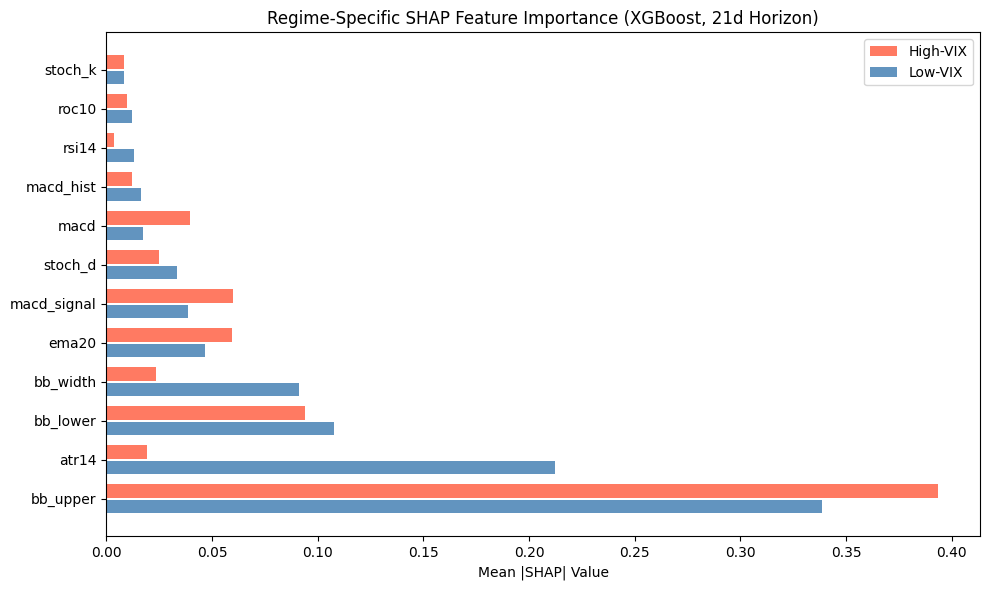

SHAP comparison plot saved.


In [5]:
top_features = importance_by_regime['Overall'].head(12).index.tolist()

high_vals  = importance_by_regime['High-VIX'][top_features]
low_vals   = importance_by_regime['Low-VIX'][top_features]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(top_features))
ax.barh(x + 0.2, high_vals.values, height=0.35, label='High-VIX', color='tomato', alpha=0.85)
ax.barh(x - 0.2, low_vals.values,  height=0.35, label='Low-VIX',  color='steelblue', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(top_features)
ax.set_xlabel('Mean |SHAP| Value')
ax.set_title('Regime-Specific SHAP Feature Importance (XGBoost, 21d Horizon)')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS / 'R07_shap_regime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP comparison plot saved.')

## 4. SHAP Beeswarm Plot (High-VIX only)

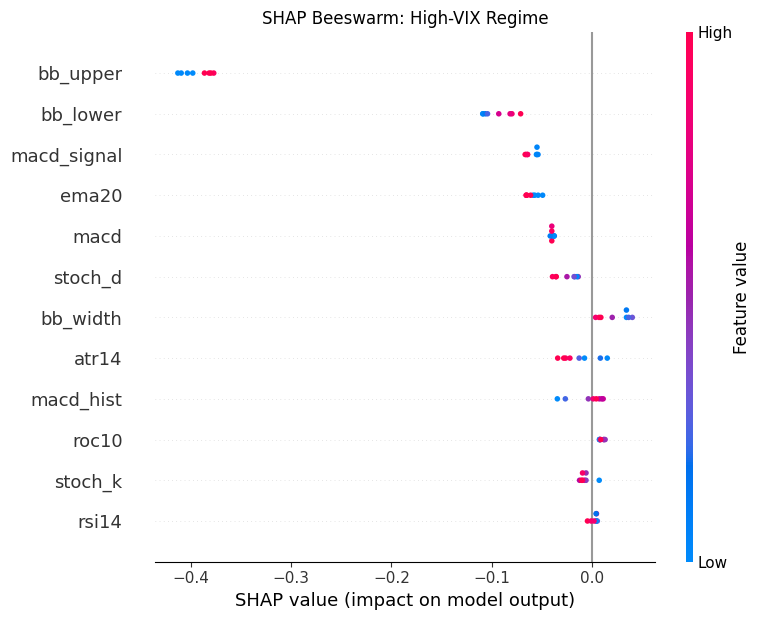

Beeswarm plot saved.


In [6]:
high_mask = regime == 'High-VIX'
shap_high = shap_values[high_mask]
X_test_high = X_test[high_mask]

shap.summary_plot(
    shap_high, X_test_high,
    feature_names=FEATURE_COLS,
    max_display=12,
    show=False,
    plot_type='dot'
)
plt.title('SHAP Beeswarm: High-VIX Regime')
plt.tight_layout()
plt.savefig(PLOTS / 'R07_shap_beeswarm_high_vix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Beeswarm plot saved.')

## 5. Feature Change Analysis: Which Features Shift Most Between Regimes?

In [7]:
shift = (importance_by_regime['High-VIX'] - importance_by_regime['Low-VIX']).sort_values(ascending=False)
print('Features with largest SHAP increase in High-VIX vs Low-VIX:')
print(shift.head(8).to_string())
print('\nFeatures with largest SHAP decrease in High-VIX vs Low-VIX:')
print(shift.tail(8).to_string())

shift.to_csv(RESULTS / 'shap_regime_shift.csv', header=['shap_diff_high_minus_low'])
print('Regime shift saved.')

Features with largest SHAP increase in High-VIX vs Low-VIX:
bb_upper        0.055238
macd            0.022098
macd_signal     0.021179
ema20           0.012667
log_ret_lag3    0.000736
log_ret_lag5    0.000616
stoch_k         0.000367
log_ret_lag1   -0.000470

Features with largest SHAP decrease in High-VIX vs Low-VIX:
log_ret_lag2   -0.000480
roc10          -0.002542
macd_hist      -0.004048
stoch_d        -0.008425
rsi14          -0.009300
bb_lower       -0.013708
bb_width       -0.067799
atr14          -0.192974
Regime shift saved.
